# Function 8 — Bayesian Optimization Campaign

This notebook documents the search for the input `(x1, ..., x8)` that **maximizes** an
unknown ("black-box") 8D function. A Gaussian Process (GP) surrogate model is fit to the
observed data, and acquisition functions (Expected Improvement, Upper Confidence Bound) are
used to decide which point to query next.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm, qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import torch
import torch.nn as nn
import torch.optim as optim

## 2. Initial Data

In [2]:
X = np.load("function_8/data/initial_inputs.npy")
y = np.load("function_8/data/initial_outputs.npy")

Additional query rounds, appended as results came in:

In [3]:
X = np.append(X, [
    [0.086742, 0.044878, 0.148373, 0.000001, 0.999999, 0.413900, 0.087100, 0.893100],
    [0.000050, 0.061737, 0.126822, 0.000050, 0.552527, 0.573729, 0.000050, 0.241814],
    [0.098365, 0.321694, 0.274773, 0.563393, 0.976643, 0.743288, 0.479267, 0.023731],
    [0.192356, 0.238634, 0.002279, 0.665361, 0.957875, 0.024156, 0.268708, 0.867175],
    [0.819043, 0.132636, 0.053945, 0.334416, 0.511216, 0.943375, 0.072411, 0.603372],
    [0.285072, 0.672366, 0.176750, 0.947100, 0.838174, 0.889650, 0.128810, 0.076014],
    [0.361520, 0.002760, 0.223279, 0.107328, 0.848316, 0.160880, 0.060393, 0.238034],
    [0.094562, 0.649763, 0.027938, 0.386260, 0.230417, 0.057540, 0.368588, 0.547980],
    [0.000099, 0.999999, 0.000099, 0.000099, 0.999999, 0.999999, 0.000099, 0.999999],
    [0.000099, 0.000099, 0.611296, 0.000099, 0.999900, 0.999900, 0.999900, 0.999900],
    [0.000001, 0.000001, 0.628520, 0.000001, 0.999999, 0.999999, 0.000001, 0.000001],
    [0.043396, 0.053307, 0.137597, 0.000025, 0.776263, 0.493814, 0.043575, 0.567457],
    [0.023396, 0.063307, 0.125597, 0.000050, 0.536263, 0.593814, 0.023575, 0.287457],
    ], axis=0)

y = np.append(y, [
    9.9035888235995,
    9.8208672019139,
    9.4727652505954,
    9.405080233989,
    8.6434519368416,
    8.8265574595184,
    9.6453593867514,
    9.2480113729385,
    8.818528621589401,
    7.674609405948,
    8.8034365487924,
    9.9122133391516,
    9.8426052732766,
    ], axis=0)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Best observed y so far: {max(y)}")

X shape: (53, 8), y shape: (53,)
Best observed y so far: 9.9122133391516


## 3. Gaussian Process Surrogate Model

Giving each of the 8 dimensions its own length-scale (ARD) lets the GP learn which inputs are
actually driving the high-yield output. A `WhiteKernel` term models observation noise.

In [4]:
d = 8
n_starts = 64  # increased for 8D complexity
current_best_y = np.max(y)

kernel = C(1.0) * Matern(length_scale=[0.5] * d,
                         length_scale_bounds=(0.01, 10),
                         nu=2.5) + WhiteKernel(noise_level=1)

gp_model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25)
gp_model.fit(X, y)

/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP.If `None` is passed,the kernel `ConstantKernel() * RBF()` is used as default.Note thatthe kernel hyperparameters are optimized during fittingunless the bounds are marked as `""fixed""`or the argument `optimizer` is set to `None`.",1**2 * Matern...noise_level=1)
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",25
,kernel__k1,"1**2 * Matern... 0.5], nu=2.5)"
,kernel__k2,WhiteKernel(noise_level=1)
,kernel__k1__k1,1**2
,kernel__k1__k2,"Matern(length... 0.5], nu=2.5)"
,kernel__k1__k1__constant_value,1.0
,kernel__k1__k1__constant_value_bounds,"(1e-05, ...)"
,kernel__k1__k2__length_scale,"[0.5, 0.5, ...]"
,kernel__k1__k2__length_scale_bounds,"(0.01, ...)"
,kernel__k1__k2__nu,2.5


In [5]:
optimized_kernel = gp_model.kernel_
length_scales = optimized_kernel.get_params()['k1__k2__length_scale']

print("--- Hyperparameter Check ---")
for i, ls in enumerate(length_scales):
    print(f"Parameter x{i+1} Length Scale: {ls:.4f}")

if np.any(np.isclose(length_scales, 0.01)) or np.any(np.isclose(length_scales, 10.0)):
    print("\nWARNING: One or more length scales are hitting the bounds. Consider widening 'length_scale_bounds'.")

--- Hyperparameter Check ---
Parameter x1 Length Scale: 3.0803
Parameter x2 Length Scale: 4.3931
Parameter x3 Length Scale: 2.4248
Parameter x4 Length Scale: 4.6634
Parameter x5 Length Scale: 6.8752
Parameter x6 Length Scale: 4.4359
Parameter x7 Length Scale: 3.1400
Parameter x8 Length Scale: 10.0000



In [6]:
optimized_noise = gp_model.kernel_.k2.noise_level
print(f"Optimized Noise Level: {optimized_noise:.6f}")

scales = gp_model.kernel_.k1.k2.length_scale
print(f"Optimized Length Scales: {scales}")

Optimized Noise Level: 0.000010
Optimized Length Scales: [ 3.08028483  4.39305565  2.42483464  4.66336699  6.87517549  4.43591994
  3.14001023 10.        ]


## 4. Acquisition Functions

### Expected Improvement (EI)
`xi=1.0` is a deliberately high exploration parameter for this 8D space — it forces the model
to look for points that could beat the current best by a significant margin. A Sobol
quasi-random sequence is used to generate well-spread starting points, and the best local
optimum found across all of them is kept.

In [7]:
def expected_improvement(x_test, gp, y_max, xi=0.01):
    x_test = np.atleast_2d(x_test)
    mu, sigma = gp.predict(x_test, return_std=True)

    sigma = np.maximum(sigma, 1e-9)  # prevent division by zero

    imp = mu - y_max - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)

    return -ei.flatten()  # negative for minimize()

sampler = qmc.Sobol(d=d, scramble=True)
initial_guesses = sampler.random(n=n_starts)

best_ei_found = np.inf
best_next_point = None

for x0 in initial_guesses:
    res = minimize(
        expected_improvement,
        x0,
        args=(gp_model, current_best_y, 1.0),  # xi set to 1.0 for exploration
        bounds=[(0, 1)] * d,
        method='L-BFGS-B'
    )

    if res.fun < best_ei_found:
        best_ei_found = res.fun
        best_next_point = res.x

print(f"Suggested Next Iteration Point (EI): {best_next_point}")

Suggested Next Iteration Point (EI): [0.07972111 0.69562685 0.14307298 0.91206168 0.8862598  0.3358276
 0.39117552 0.96139921]


Third iteration: continuing to exploit the current best region with high exploration weight.

### Upper Confidence Bound (UCB)
`kappa` controls the exploration/exploitation trade-off.

In [8]:
def ucb_loss(x_test, kappa=10):
    mu, sigma = gp_model.predict(x_test.reshape(1, -1), return_std=True)
    ucb = mu + kappa * sigma
    return -ucb

x_init = X[np.argmax(y)]  # start from current best
res = minimize(ucb_loss, x_init, bounds=[(0, 1)] * 8, method='L-BFGS-B')

print(f"Current Best Y: {np.max(y)}")
print(f"Next Suggested Point (UCB): {res.x}")

Current Best Y: 9.9122133391516
Next Suggested Point (UCB): [0.        0.        0.        0.        1.        0.        0.6602482
 0.       ]


Fourth iteration: tighten the length scales — lowering the upper bound of
`length_scale_bounds` from 10.0 to 1.0–2.0 would force the model to acknowledge that there is
finer detail in the landscape than the current fit assumes. This refinement was planned for a
follow-up run but not yet re-fit here.

In [9]:
next_point = best_next_point  # EI candidate is used as the final suggestion

### Ranked Observations
A quick sanity check on where the current samples rank by yield.

In [10]:
sorted_indices = np.argsort(y)
sorted_values = y[sorted_indices]

print(f"{'Rank':<6} | {'Orig Index':<10} | {'Value':<10}")
print("-" * 32)
for rank, idx in enumerate(sorted_indices):
    print(f"{rank:<6} | {idx:<10} | {sorted_values[rank]:.2f}")

Rank   | Orig Index | Value     
--------------------------------
0      | 9          | 5.59
1      | 21         | 5.84
2      | 34         | 6.40
3      | 24         | 6.45
4      | 17         | 6.77
5      | 11         | 6.79
6      | 27         | 6.89
7      | 1          | 7.01
8      | 33         | 7.11
9      | 16         | 7.13
10     | 7          | 7.30
11     | 20         | 7.31
12     | 6          | 7.33
13     | 13         | 7.38
14     | 0          | 7.40
15     | 18         | 7.43
16     | 38         | 7.44
17     | 37         | 7.46
18     | 49         | 7.67
19     | 29         | 7.69
20     | 10         | 7.85
21     | 30         | 7.92
22     | 8          | 7.96
23     | 36         | 7.98
24     | 28         | 8.04
25     | 15         | 8.16
26     | 32         | 8.28
27     | 3          | 8.28
28     | 31         | 8.42
29     | 2          | 8.46
30     | 35         | 8.47
31     | 5          | 8.54
32     | 4          | 8.61
33     | 44         | 8.64
34     | 50     

## 5. Supplementary Analysis — Neural Network Saliency

Existing samples are manually labeled "positive" (high-yield, listed indices) or "negative",
and a small neural network is trained on that split as a sanity check on whether the
acquisition function's suggested `next_point` also looks promising from a classification
standpoint. This is exploratory and not part of the core GP/acquisition-function decision loop.

In [11]:
y_labels = np.zeros(len(X))
positive_indices = [40, 41, 14, 42, 43, 26, 39, 19]
y_labels[positive_indices] = 1

X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)
y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

nn_model_deep = nn.Sequential(
    nn.Linear(8, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(nn_model_deep.parameters(), lr=0.01)
criterion = nn.BCELoss()

for _ in range(2000):
    optimizer.zero_grad()
    outputs = nn_model_deep(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

X_tensor.grad.zero_()
output = nn_model_deep(X_tensor)
output.backward(torch.ones_like(output))

deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")

Point | Deep Importance Score
 0    | 0.0000
 1    | 0.0000
 2    | 0.0001
 3    | 0.0000
 4    | 0.0001
 5    | 0.0000
 6    | 0.0000
 7    | 0.0000
 8    | 0.0000
 9    | 0.0000
10    | 0.0000
11    | 0.0000
12    | 0.0187
13    | 0.0000
14    | 0.2074
15    | 0.0000
16    | 0.0000
17    | 0.0000
18    | 0.0000
19    | 0.0287
20    | 0.0003
21    | 0.0000
22    | 0.0000
23    | 0.0000
24    | 0.0000
25    | 0.0322
26    | 0.2065
27    | 0.0000
28    | 0.0000
29    | 0.0005
30    | 0.0000
31    | 0.0000
32    | 0.0000
33    | 0.0000
34    | 0.0000
35    | 0.0000
36    | 0.0000
37    | 0.0273
38    | 0.0000
39    | 0.0738
40    | 0.1894
41    | 6.8533
42    | 0.0000
43    | 0.0000
44    | 0.0000
45    | 0.1199
46    | 0.0017
47    | 0.0206
48    | 0.0006
49    | 0.0000
50    | 0.1576
51    | 0.4595
52    | 6.5690


In [12]:
nn_model_deep.eval()
sample_input = torch.tensor(np.array([next_point]), dtype=torch.float32)

with torch.no_grad():
    prediction_prob = nn_model_deep(sample_input)

print(f"Next point: {next_point}")
print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")

Next point: [0.07972111 0.69562685 0.14307298 0.91206168 0.8862598  0.3358276
 0.39117552 0.96139921]
Probability of being Positive (Class 1): 0.7844
Predicted Class: 1


## 6. Results Summary

Observed yield over the most recent iterations:

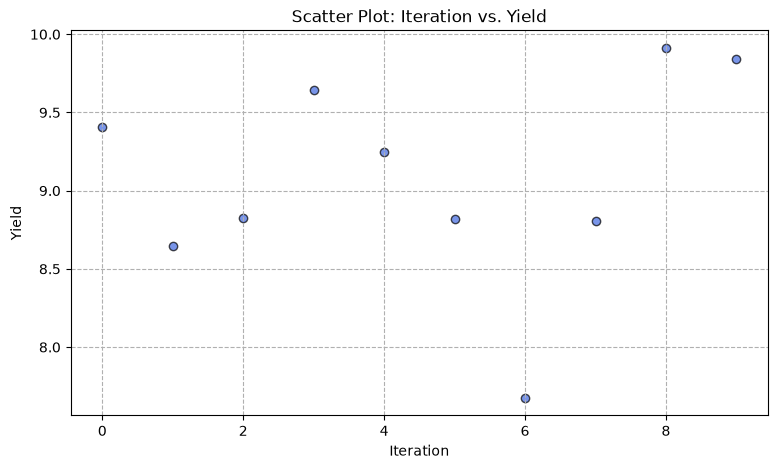

In [13]:
plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(0, 10)), y[-10:], color="royalblue", alpha=0.7, edgecolors="k"
)
plt.title("Scatter Plot: Iteration vs. Yield")
plt.xlabel("Iteration")
plt.ylabel("Yield")
plt.grid(True, linestyle="--", alpha=1)
plt.show()